<p align="center">
  <img src="docs/images/00-citibike-banner.jpg" alt="NYC Citi Bike" width="640">
</p>

# NYC Citi Bike — Demand & Rider Behaviour Analysis

This notebook supports the [project case study](README.md). It turns a 2017 Jersey City Citi Bike extract into one reproducible analysis frame, documents every cleaning decision, and tests how demand, rider type, age, and trip duration relate.

> **Scope:** 20,400 supplied records, January–December 2017. The supplied CSV already includes engineered fields such as age, age group, weekday, season, and trip duration in minutes; it is therefore a prepared learning extract rather than untouched source-system data.

## 1. Setup and data audit

The analysis keeps the original text values long enough to remove exact duplicate rows. This matters because some equivalent timestamps use different text formats; parsing first would silently collapse additional records.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("data/citibike_jc_2017_prepared.csv")
raw = pd.read_csv(DATA_PATH)

print(f"Shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
display(raw.head(3))

Shape: 20,400 rows × 17 columns


,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday
0,01-01-17 00:38,1-1-17 01:03,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday
1,01-01-17 01:47,01-01-17 01:58,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
2,01-01-17 01:47,01-01-17 01:58,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday


In [2]:
audit = pd.DataFrame({
    "metric": ["Rows", "Columns", "Exact duplicate rows", "Rows containing a missing value"],
    "value": [len(raw), raw.shape[1], raw.duplicated().sum(), raw.isna().any(axis=1).sum()],
})
display(audit)

missing = raw.isna().sum().loc[lambda s: s.gt(0)].sort_values(ascending=False)
display(missing.rename("missing_values").to_frame())

,metric,value
0,Rows,20400
1,Columns,17
2,Exact duplicate rows,1950
3,Rows containing a missing value,1


,missing_values
End Station Name,1


## 2. Cleaning

Cleaning is deliberately explicit:

1. Remove exact duplicate source rows.
2. Remove rows with missing values because the affected fields are required for the planned segmentation.
3. Parse timestamps with `dayfirst=True` to match the source strings.
4. Parse trip duration as numeric and validate key ranges.

Extreme trip durations are **flagged, not deleted**. The primary results therefore use all 18,449 cleaned trips; robust statistics are used where outliers would distort the mean.

In [3]:
bikes = raw.drop_duplicates().dropna().copy()

bikes["Start Time"] = pd.to_datetime(bikes["Start Time"], dayfirst=True, format="mixed")
bikes["Stop Time"] = pd.to_datetime(bikes["Stop Time"], dayfirst=True, format="mixed")
bikes["Trip_Duration_in_min"] = pd.to_numeric(
    bikes["Trip_Duration_in_min"].astype(str).str.replace(",", "", regex=False),
    errors="raise",
)
bikes["Age"] = pd.to_numeric(bikes["Age"], errors="raise")
bikes["is_over_60_min"] = bikes["Trip_Duration_in_min"].gt(60)

cleaning_summary = pd.DataFrame({
    "stage": ["Supplied records", "After exact deduplication", "After removing incomplete rows"],
    "rows": [len(raw), len(raw.drop_duplicates()), len(bikes)],
})
display(cleaning_summary)

assert len(bikes) == 18_449
assert bikes["Trip_Duration_in_min"].ge(0).all()
assert bikes["Age"].between(18, 100).all()
assert bikes["Start Time"].notna().all() and bikes["Stop Time"].notna().all()
print("Validation checks passed.")

,stage,rows
0,Supplied records,20400
1,After exact deduplication,18450
2,After removing incomplete rows,18449


Validation checks passed.


## 3. Trip duration and outliers

The mean and median are reported together because duration is strongly right-skewed. Trips above 60 minutes are retained as potentially genuine rides or operational/data-quality events; the dataset does not provide enough evidence to classify them.

In [4]:
duration_summary = bikes["Trip_Duration_in_min"].agg(["count", "mean", "median", "min", "max"]).to_frame("minutes")
duration_summary.loc[["mean", "median"], "minutes"] = duration_summary.loc[["mean", "median"], "minutes"].round(1)
display(duration_summary)
print(f"Trips longer than 60 minutes: {bikes['is_over_60_min'].sum():,}")

,minutes
count,18449.0
mean,9.6
median,5.0
min,1.0
max,6515.0


Trips longer than 60 minutes: 103


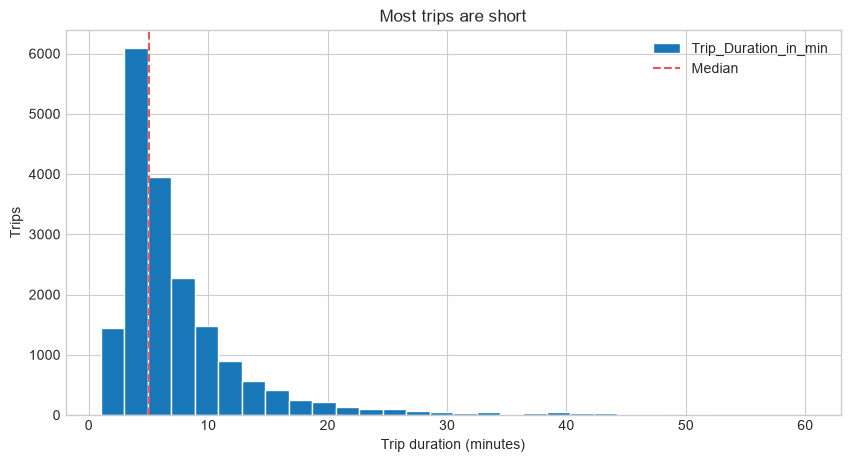

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bikes.loc[bikes["Trip_Duration_in_min"].le(60), "Trip_Duration_in_min"].plot(
    kind="hist", bins=30, color="#1877B8", edgecolor="white", ax=ax
)
ax.axvline(bikes["Trip_Duration_in_min"].median(), color="#E45756", linestyle="--", label="Median")
ax.set(title="Most trips are short", xlabel="Trip duration (minutes)", ylabel="Trips")
ax.legend()
plt.show()

## 4. Station demand

Pickup counts show where trips begin, not whether stations lack capacity. Rebalancing recommendations would need station capacity and time-of-day availability data as a next step.

In [6]:
station_demand = bikes["Start Station Name"].value_counts().head(10)
display(station_demand.rename("trips").to_frame())

top_three_share = station_demand.head(3).sum() / len(bikes)
print(f"Top-three station share: {top_three_share:.1%}")

,trips
Start Station Name,
Grove St PATH,2319
Exchange Place,1342
Hamilton Park,1185
Sip Ave,1184
Morris Canal,768
Newport PATH,707
City Hall,622
Van Vorst Park,580
Newark Ave,554


Top-three station share: 26.3%


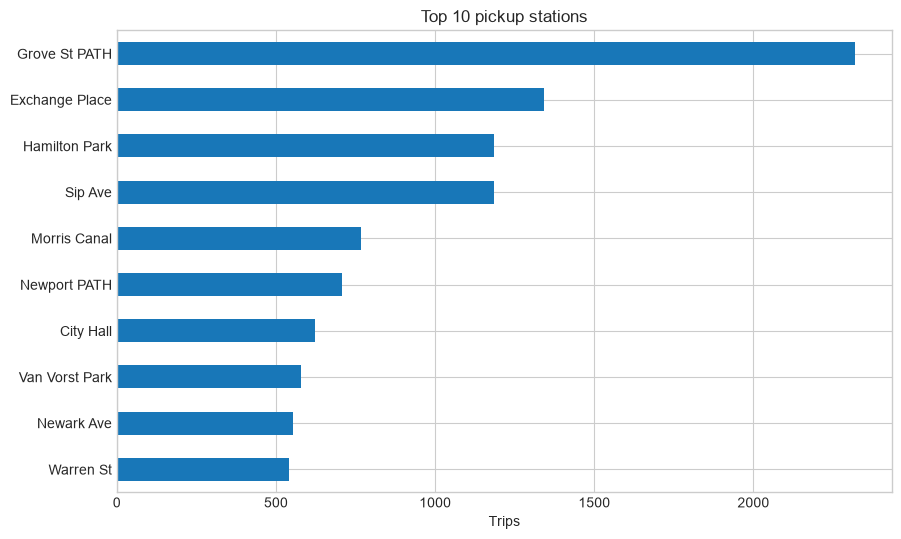

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
station_demand.sort_values().plot(kind="barh", color="#1877B8", ax=ax)
ax.set(title="Top 10 pickup stations", xlabel="Trips", ylabel="")
plt.show()

## 5. Rider segments and weekday patterns

The weekday pattern is consistent with commuter use, especially because PATH-linked stations rank highly. That remains a hypothesis: confirming it would require time-of-day and trip-flow analysis.

In [8]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_users = pd.crosstab(bikes["Weekday"], bikes["User Type"]).reindex(weekday_order)
weekday_users["Total"] = weekday_users.sum(axis=1)
display(weekday_users)

subscriber_share = bikes["User Type"].eq("Subscriber").mean()
weekday_avg = weekday_users.loc[weekday_order[:5], "Total"].mean()
weekend_avg = weekday_users.loc[weekday_order[5:], "Total"].mean()
print(f"Subscriber share: {subscriber_share:.1%}")
print(f"Average weekday trips: {weekday_avg:,.0f}")
print(f"Average weekend-day trips: {weekend_avg:,.0f}")
print(f"Weekday uplift: {weekday_avg / weekend_avg - 1:.0%}")

User Type,One-time user,Subscriber,Total
Weekday,,,
Monday,57,2715,2772
Tuesday,30,2647,2677
Wednesday,43,3590,3633
Thursday,20,3239,3259
Friday,30,2645,2675
Saturday,102,1612,1714
Sunday,68,1651,1719


Subscriber share: 98.1%
Average weekday trips: 3,003
Average weekend-day trips: 1,716
Weekday uplift: 75%


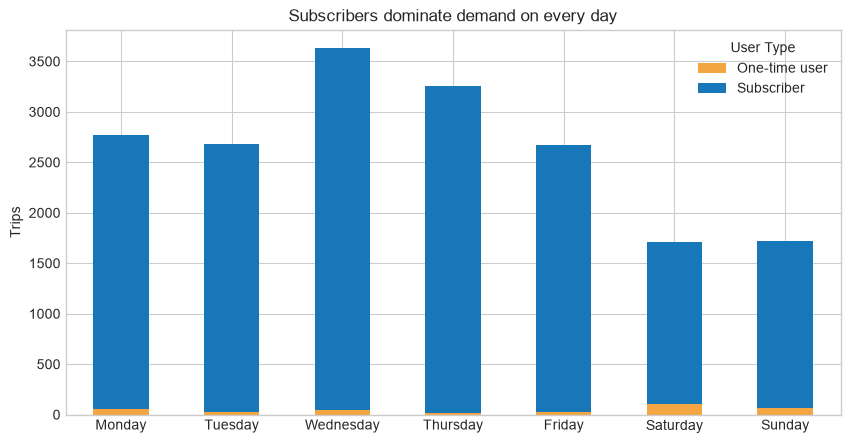

In [9]:
plot_data = weekday_users.drop(columns="Total")
fig, ax = plt.subplots(figsize=(10, 5))
plot_data.plot(kind="bar", stacked=True, color=["#F2A541", "#1877B8"], ax=ax)
ax.set(title="Subscribers dominate demand on every day", xlabel="", ylabel="Trips")
ax.tick_params(axis="x", rotation=0)
plt.show()

## 6. Age, duration, and the danger of averages

Age-group means are compared with medians and sample sizes. This exposes whether a small number of extreme trips is driving an apparent segment difference.

In [10]:
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
age_summary = (
    bikes.groupby("Age Groups", observed=True)["Trip_Duration_in_min"]
    .agg(trips="size", mean="mean", median="median")
    .reindex(age_order)
)
age_summary[["mean", "median"]] = age_summary[["mean", "median"]].round(1)
display(age_summary)

oldest = bikes.loc[bikes["Age Groups"].eq("75+"), "Trip_Duration_in_min"]
largest = oldest.max()
print(f"Largest 75+ trip: {largest:,.0f} minutes")
print(f"Share of 75+ minutes from that trip: {largest / oldest.sum():.1%}")
print(f"75+ mean without that trip: {oldest.loc[oldest.ne(largest)].mean():.1f} minutes")

,trips,mean,median
Age Groups,,,
18-24,56,11.9,10.0
25-34,4434,9.0,6.0
35-44,8377,10.3,5.0
45-54,3238,8.1,5.0
55-64,1600,10.2,6.0
65-74,687,7.4,6.0
75+,57,47.9,4.0


Largest 75+ trip: 2,422 minutes
Share of 75+ minutes from that trip: 88.8%
75+ mean without that trip: 5.5 minutes


Pearson correlation between age and trip duration: -0.002


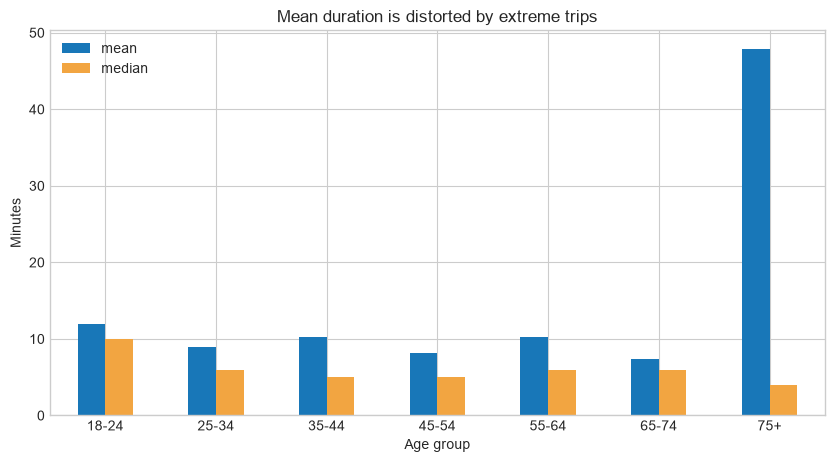

In [11]:
correlation = bikes[["Age", "Trip_Duration_in_min"]].corr().iloc[0, 1]
print(f"Pearson correlation between age and trip duration: {correlation:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
age_summary[["mean", "median"]].plot(kind="bar", color=["#1877B8", "#F2A541"], ax=ax)
ax.set(title="Mean duration is distorted by extreme trips", xlabel="Age group", ylabel="Minutes")
ax.tick_params(axis="x", rotation=0)
plt.show()

## 7. Conclusions

- **Demand is concentrated.** Grove St PATH leads pickup demand, and the top three stations generate about 26% of cleaned trips.
- **Usage is subscription-led.** Subscribers account for roughly 98% of trips, while average weekday demand is about 75% above an average weekend day.
- **The median describes a typical trip better than the mean.** A small number of very long records produce strong right skew.
- **Age is not useful here as a duration predictor.** Pearson's correlation is approximately zero, and the apparently high 75+ mean is driven by one extreme trip.
- **Operational recommendations need additional evidence.** Hourly demand, station capacity, bike availability, origin–destination flows, weather, and service incidents would be needed before making rebalancing or causal claims.

### Recommended next steps

1. Analyse hourly pickup and return flows at PATH-linked stations.
2. Combine demand with capacity and availability data to measure actual shortages.
3. Define operational rules for implausibly long rentals with domain owners rather than deleting records ad hoc.
4. Investigate weekend casual-user conversion with pricing and campaign data.

### Limitations

This is a small prepared learning extract, not the complete Citi Bike trip-history archive. It contains derived demographic and calendar fields, has no documented sampling method in the repository, and cannot establish why observed patterns occur. Findings should be treated as descriptive and scoped to this extract.